In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT uid, timestamp
FROM checker
WHERE uid NOT LIKE 'admin_%' AND timestamp IS NOT NULL
"""
df = pd.io.sql.read_sql(query, conn)

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.strftime('%a')

In [5]:
user_totals = df.groupby('uid').size().sort_values(ascending=False)
col_order = user_totals.index.tolist()

In [6]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_day = pd.crosstab(df['weekday'], df['uid']).reindex(day_order, fill_value=0)[col_order]

In [10]:
pivot_day.shape

(7, 30)

In [7]:
pivot_hour = pd.crosstab(df['hour'], df['uid']).reindex(range(24), fill_value=0)[col_order]

In [11]:
pivot_hour.shape

(24, 30)

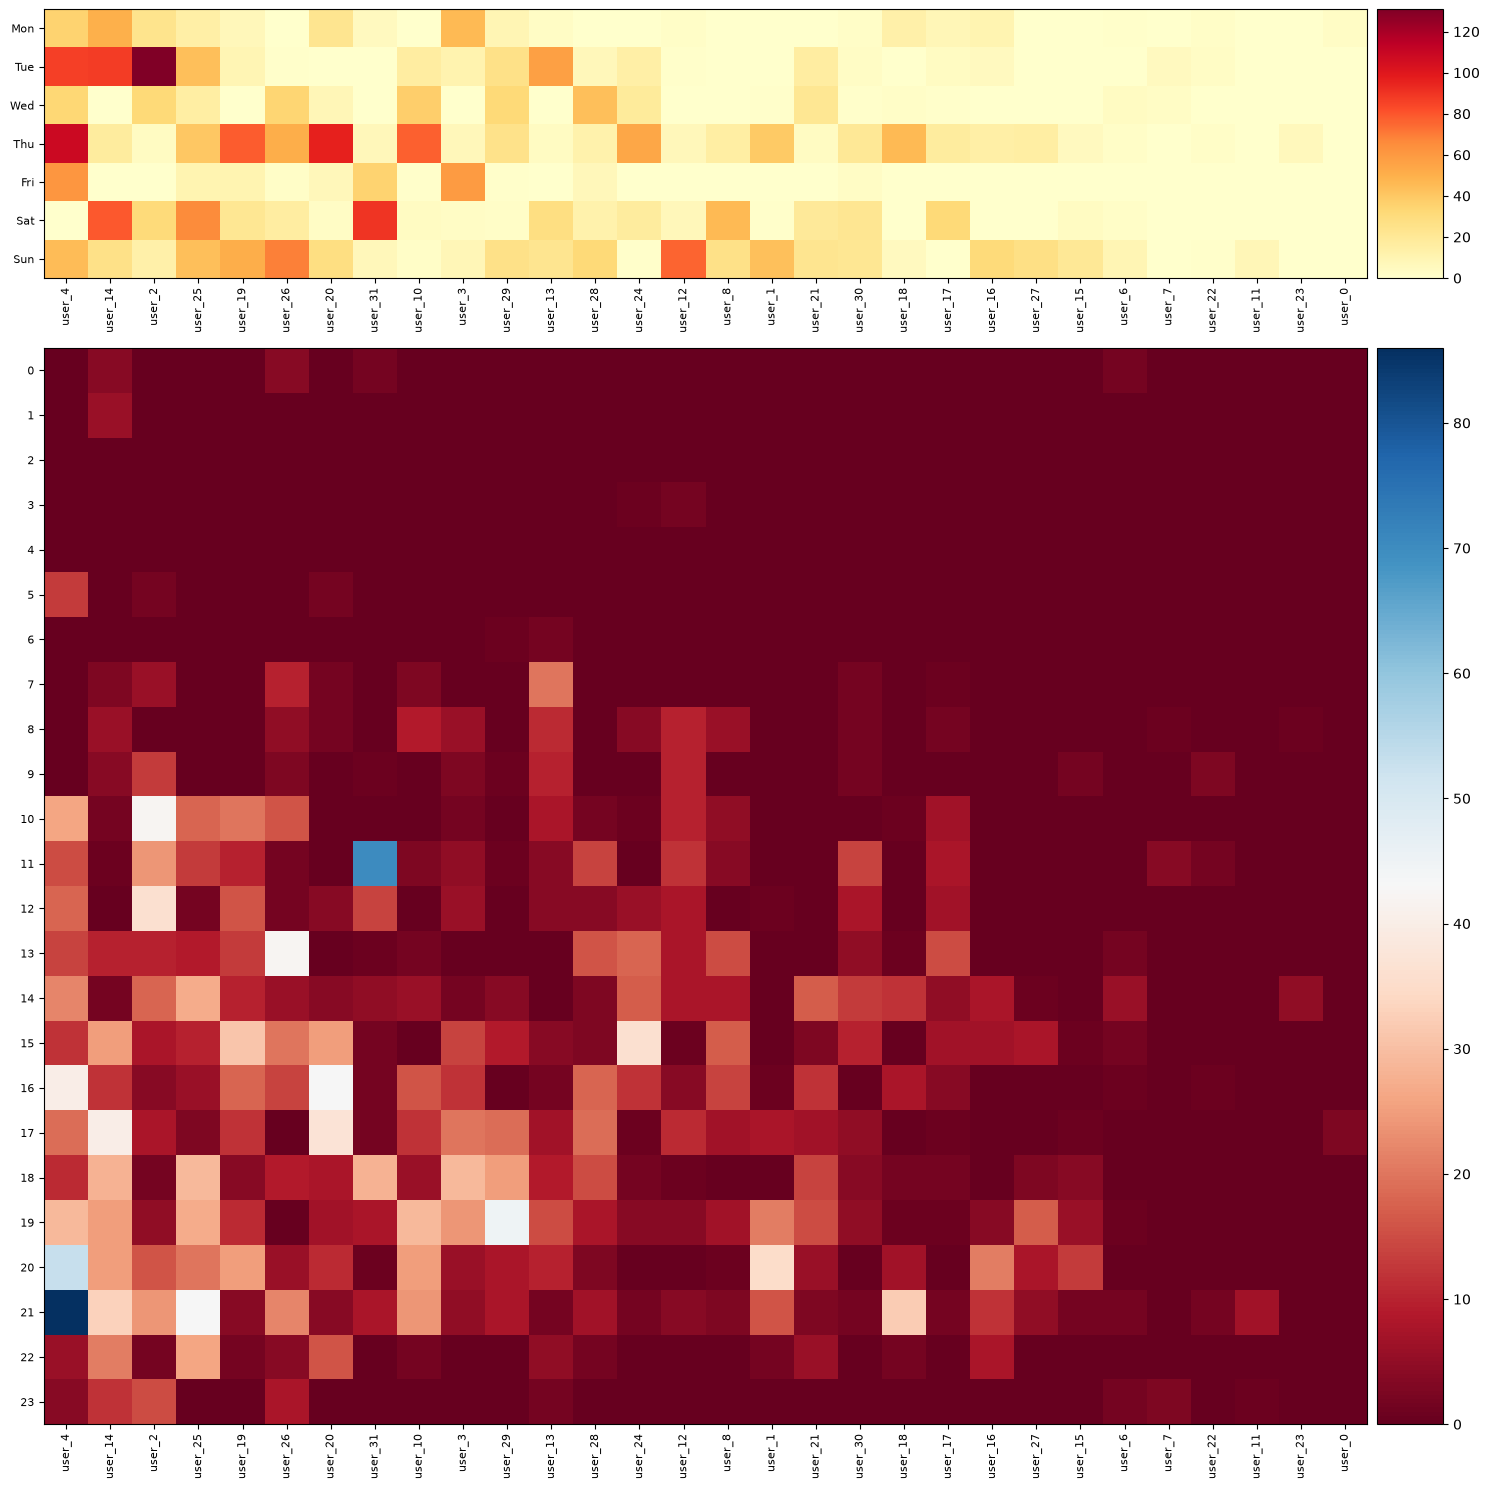

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15), gridspec_kw={'height_ratios': [1, 4]})

im1 = ax1.imshow(pivot_day, aspect='auto', cmap='YlOrRd')
ax1.set_xticks(range(len(pivot_day.columns)))
ax1.set_xticklabels(pivot_day.columns, rotation=90, fontsize=8)
ax1.set_yticks(range(len(pivot_day.index)))
ax1.set_yticklabels(pivot_day.index, fontsize=8)
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im1, cax=cax1)

im2 = ax2.imshow(pivot_hour, aspect='auto', cmap='RdBu')
ax2.set_xticks(range(len(pivot_hour.columns)))
ax2.set_xticklabels(pivot_hour.columns, rotation=90, fontsize=8)
ax2.set_yticks(range(len(pivot_hour.index)))
ax2.set_yticklabels(pivot_hour.index, fontsize=8)
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

In [9]:
conn.close()

У какого пользователя больше всего коммитов во Вт?

Ответ: user_2

У какого пользователя больше всего коммитов в Чт?

Ответ: user_4

В какой день недели пользователи не любят много коммитить?

Ответ: Fri

Какой пользователь и в который час сделал наибольшее число коммитов?

Ответ: user_4, 21